# 2. A tour of `snia.cosmology`

Methods of `FLRW`.

The class takes exactly two parameters and no $H_0$.
Distances are dimensionless, in units of $c/H_0$; times are in Hubble times
$1/H_0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from snia.cosmology import FLRW

plt.rcParams["figure.figsize"] = (7, 4)

lcdm = FLRW(0.3, 0.7)

## 1. Building a model

`omega_k` and `q0` are **derived properties**, recomputed each time they are
read, so they cannot fall out of sync with the parameters.

In [2]:
for omega_m, omega_lambda in [(0.3, 0.7), (1.0, 0.0), (0.3, 0.0), (0.3, 1.2)]:
    model = FLRW(omega_m, omega_lambda)
    geometry = "flat" if model.omega_k == 0 else ("open" if model.omega_k > 0 else "closed")
    motion = "accelerating" if model.q0 < 0 else "decelerating"
    print(f"({omega_m}, {omega_lambda}):  omega_k = {model.omega_k:+.2f}   "
          f"q0 = {model.q0:+.3f}   {geometry}, {motion}")

(0.3, 0.7):  omega_k = +0.00   q0 = -0.550   flat, accelerating
(1.0, 0.0):  omega_k = +0.00   q0 = +0.500   flat, decelerating
(0.3, 0.0):  omega_k = +0.70   q0 = +0.150   open, decelerating
(0.3, 1.2):  omega_k = -0.50   q0 = -1.050   closed, accelerating


## 2. All the methods

Every one accepts a scalar or an array and returns the matching shape.

In [3]:
methods = [
    "E", "E_squared",
    "comoving_distance", "transverse_comoving_distance",
    "angular_diameter_distance", "luminosity_distance", "distance_modulus",
    "lookback_time", "age", "comoving_volume_element", "deceleration_parameter",
]

print(f"{'method':32s} value at z = 1")
for name in methods:
    print(f"{name:32s} {getattr(lcdm, name)(1.0):>10.6f}")

method                           value at z = 1
E                                  1.760682
E_squared                          3.100000
comoving_distance                  0.771427
transverse_comoving_distance       0.771427
angular_diameter_distance          0.385714
luminosity_distance                1.542854
distance_modulus                   0.941624
lookback_time                      0.552340
age                                0.411760
comoving_volume_element            0.337994
deceleration_parameter             0.161290


In [4]:
print("scalar in, scalar out :", lcdm.luminosity_distance(0.5))
print("array  in, array  out :", lcdm.luminosity_distance(np.array([0.1, 0.5, 1.0])))
print("2-D also works, shape :", lcdm.luminosity_distance(np.zeros((2, 3))).shape)

scalar in, scalar out : 0.6614765024168321
array  in, array  out : [0.10747767 0.6614765  1.54285414]
2-D also works, shape : (2, 3)


## 3. Distances

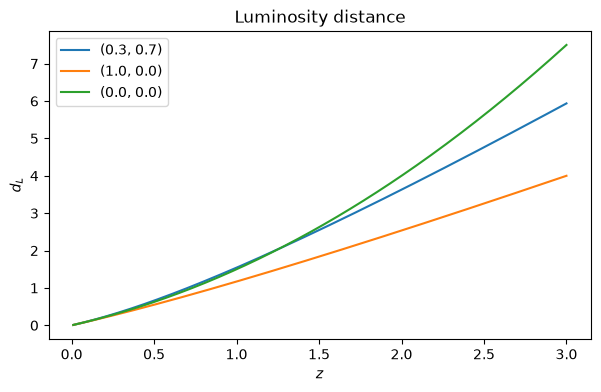

In [5]:
z = np.linspace(0.01, 3, 300)

for omega_m, omega_lambda in [(0.3, 0.7), (1.0, 0.0), (0.0, 0.0)]:
    model = FLRW(omega_m, omega_lambda)
    plt.plot(z, model.luminosity_distance(z), label=f"({omega_m}, {omega_lambda})")
plt.xlabel("$z$")
plt.ylabel("$d_L$")
plt.title("Luminosity distance")
plt.legend()
plt.show()

### A closed universe can make $d_L$ decrease

For $\Omega_k < 0$ the sine turns over once $u = \sqrt{|\Omega_k|}\,I$ passes
$\pi/2$, so $D_M$ starts falling even though $I$ keeps growing. The closed
geometry focuses light, and more distant sources can appear brighter. When $u$
reaches $\pi$ the light cone has crossed the antipode and $D_M$ goes negative —
one of the two things `is_valid` rejects.

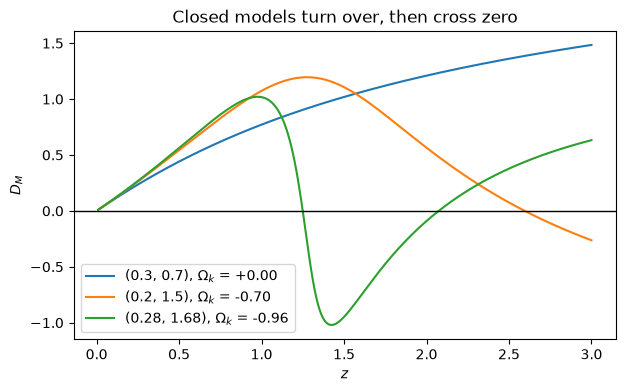

In [6]:
z = np.linspace(0.01, 3, 300)

for omega_m, omega_lambda in [(0.3, 0.7), (0.2, 1.5), (0.28, 1.68)]:
    model = FLRW(omega_m, omega_lambda)
    plt.plot(z, model.transverse_comoving_distance(z),
             label=f"({omega_m}, {omega_lambda}), $\\Omega_k$ = {model.omega_k:+.2f}")
plt.axhline(0, color="k", lw=1)
plt.xlabel("$z$")
plt.ylabel("$D_M$")
plt.title("Closed models turn over, then cross zero")
plt.legend()
plt.show()

## 4. Cosmic time

$$
H_0 t_L(z) = \int_0^z \frac{dz'}{(1+z')E(z')},
\qquad
H_0 t(z) = \int_0^{\sqrt{a}} \frac{2x^{2}\,dx}{\sqrt{\Omega_m + \Omega_k x^{2} + \Omega_\Lambda x^{6}}}
$$

with $a = 1/(1+z)$. The age uses two substitutions: $a = 1/(1+z)$ makes the
$z$-range finite, and $a = x^{2}$ removes the singularity the integrand would
have at the Big Bang.

In [7]:
HUBBLE_TIME_GYR = 9.778 / 0.7        # 1/H0 in Gyr for h = 0.7

print(f"{'model':28s} {'H0 t0':>8}   {'age (Gyr)':>10}")
for omega_m, omega_lambda, name in [
    (0.3, 0.7, "LCDM (0.3, 0.7)"),
    (1.0, 0.0, "Einstein-de Sitter = 2/3"),
    (0.0, 0.0, "empty (Milne) = 1"),
    (0.0, 1.0, "de Sitter, no Big Bang"),
]:
    age = FLRW(omega_m, omega_lambda).age(0.0)
    print(f"{name:28s} {age:8.5f}   {age * HUBBLE_TIME_GYR:10.3f}")

model                           H0 t0    age (Gyr)
LCDM (0.3, 0.7)               0.96410       13.467
Einstein-de Sitter = 2/3      0.66667        9.312
empty (Milne) = 1             1.00000       13.969
de Sitter, no Big Bang            inf          inf


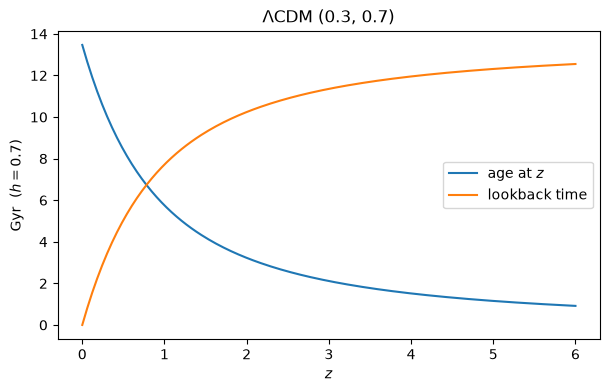

age today       = 13.47 Gyr
age + lookback  = 13.47 Gyr at z=1   (must equal the age today)


In [8]:
z = np.linspace(0, 6, 200)

plt.plot(z, lcdm.age(z) * HUBBLE_TIME_GYR, label="age at $z$")
plt.plot(z, lcdm.lookback_time(z) * HUBBLE_TIME_GYR, label="lookback time")
plt.xlabel("$z$")
plt.ylabel("Gyr  ($h = 0.7$)")
plt.title(r"$\Lambda$CDM (0.3, 0.7)")
plt.legend()
plt.show()

print(f"age today       = {lcdm.age(0.0) * HUBBLE_TIME_GYR:.2f} Gyr")
print(f"age + lookback  = {(lcdm.age(1.0) + lcdm.lookback_time(1.0)) * HUBBLE_TIME_GYR:.2f} Gyr at z=1"
      f"   (must equal the age today)")

## 5. Volume element and deceleration

$$
\frac{dV_C}{dz\,d\Omega} = \frac{D_M^{2}}{E(z)},
\qquad
q(z) = \frac{\tfrac12\Omega_m(1+z)^{3} - \Omega_\Lambda}{E^{2}(z)}
$$

$q$ comes from $q = \tfrac12\sum_i\Omega_i(z)(1+3w_i)$: matter ($w=0$) gives
$\Omega_m(z)/2$, $\Lambda$ ($w=-1$) gives $-\Omega_\Lambda(z)$, curvature gives
nothing. Negative $q$ means accelerating.

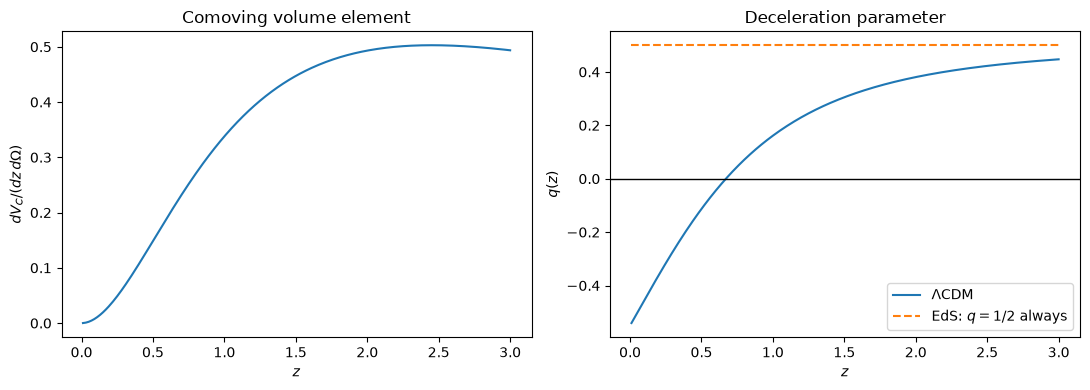

q0 = -0.550
acceleration begins where q = 0, at z = 0.6711
check: q(0.6711) = +5.3e-17


In [9]:
z = np.linspace(0.01, 3, 300)

figure, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(z, lcdm.comoving_volume_element(z))
left.set_xlabel("$z$")
left.set_ylabel(r"$dV_C/(dz\,d\Omega)$")
left.set_title("Comoving volume element")

right.plot(z, lcdm.deceleration_parameter(z), label=r"$\Lambda$CDM")
right.plot(z, FLRW(1.0, 0.0).deceleration_parameter(z), "--", label="EdS: $q = 1/2$ always")
right.axhline(0, color="k", lw=1)
right.set_xlabel("$z$")
right.set_ylabel("$q(z)$")
right.set_title("Deceleration parameter")
right.legend()
plt.tight_layout()
plt.show()

z_transition = (2 * 0.7 / 0.3) ** (1 / 3) - 1
print(f"q0 = {lcdm.q0:+.3f}")
print(f"acceleration begins where q = 0, at z = {z_transition:.4f}")
print(f"check: q({z_transition:.4f}) = {lcdm.deceleration_parameter(z_transition):+.1e}")

## 6. Which parameter values are usable?

`is_valid(z_max)` returns `False` in two situations:

1. **No Big Bang** — $E^{2}(z) \le 0$ somewhere on $[0, z_{\max}]$, so the model
   has a turning point and there is no continuous past light cone.
2. **Past the antipode** — $E^{2} > 0$ throughout, but the closed geometry has
   carried $u$ beyond $\pi$, so $D_M \le 0$.

The second is easy to miss: it needs $E^2$ to stay positive while $I$ grows
large, which happens for models that nearly stall at a turning point. The
likelihood turns `False` into $-\infty$.

In [10]:
for omega_m, omega_lambda, description in [
    (0.3, 0.7, "LCDM"),
    (0.1, 2.5, "no Big Bang: E^2 goes negative"),
    (0.28, 1.68, "loiters, then passes the antipode"),
]:
    model = FLRW(omega_m, omega_lambda)
    grid = np.linspace(0, 1.414, 500)
    print(f"({omega_m}, {omega_lambda})  {description}")
    print(f"     min E^2 on [0, 1.414] = {model.E_squared(grid).min():+.4f}")
    print(f"     min D_M               = {model.transverse_comoving_distance(grid).min():+.4f}")
    print(f"     is_valid(1.414)       = {model.is_valid(1.414)}\n")

(0.3, 0.7)  LCDM
     min E^2 on [0, 1.414] = +1.0000
     min D_M               = +0.0000
     is_valid(1.414)       = True

(0.1, 2.5)  no Big Bang: E^2 goes negative
     min E^2 on [0, 1.414] = -5.4171
     min D_M               = +0.0000
     is_valid(1.414)       = False

(0.28, 1.68)  loiters, then passes the antipode
     min E^2 on [0, 1.414] = +0.0082
     min D_M               = -1.0188
     is_valid(1.414)       = False



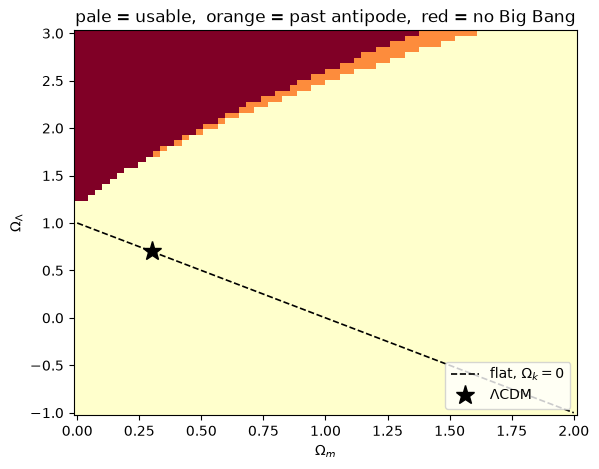

usable                : 84.1%
past the antipode     : 1.6%
no Big Bang           : 14.3%


In [11]:
# Map the two rejection modes over the prior box.
omega_m_axis = np.linspace(0.0, 2.0, 70)
omega_lambda_axis = np.linspace(-1.0, 3.0, 70)
grid = np.linspace(0, 1.414, 300)

status = np.zeros((omega_lambda_axis.size, omega_m_axis.size))
for row, omega_lambda in enumerate(omega_lambda_axis):
    for col, omega_m in enumerate(omega_m_axis):
        model = FLRW(omega_m, omega_lambda)
        if np.any(model.E_squared(grid) <= 0):
            status[row, col] = 2        # no Big Bang
        elif not model.is_valid(1.414):
            status[row, col] = 1        # past the antipode

plt.figure(figsize=(6.5, 5))
plt.pcolormesh(omega_m_axis, omega_lambda_axis, status, cmap="YlOrRd", shading="auto")
plt.plot([0, 2], [1, -1], "k--", lw=1.2, label=r"flat, $\Omega_k = 0$")
plt.plot(0.3, 0.7, "k*", ms=14, label=r"$\Lambda$CDM")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$\Omega_\Lambda$")
plt.title("pale = usable,  orange = past antipode,  red = no Big Bang")
plt.legend(loc="lower right")
plt.show()

print(f"usable                : {(status == 0).mean():.1%}")
print(f"past the antipode     : {(status == 1).mean():.1%}")
print(f"no Big Bang           : {(status == 2).mean():.1%}")